In [188]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import getpass
import act

In [7]:
# Note - recommended ARM Live token to be set as an environmental variable

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
sonde_datastream = 'nsasondewnpnC1.b1'
intp_datastream = 'nsainterpolatedsondeC1.c1'

startdate = '2015-06-13'
enddate = '2015-06-14'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
sondes = act.discovery.download_arm_data(arm_username, arm_token, sonde_datastream, startdate, enddate)
intp = act.discovery.download_arm_data(arm_username, arm_token, intp_datastream, startdate, enddate)

Enter ARM username:  trinke
Enter ARM token (hidden):  ········


[DOWNLOADING] nsasondewnpnC1.b1.20150613.054800.cdf
[DOWNLOADING] nsasondewnpnC1.b1.20150613.172200.cdf

If you use these data to prepare a publication, please cite:

Keeler, E., Burk, K., & Kyrouac, J. Balloon-Borne Sounding System (SONDEWNPN),
2015-06-13 to 2015-06-14, North Slope Alaska (NSA), Central Facility, Barrow AK
(C1). Atmospheric Radiation Measurement (ARM) User Facility.
https://doi.org/10.5439/1595321

[DOWNLOADING] nsainterpolatedsondeC1.c1.20150613.000030.nc

If you use these data to prepare a publication, please cite:

Jensen, M., Giangrande, S., Fairless, T., & Zhou, A. Interpolated Sonde
(INTERPOLATEDSONDE), 2015-06-13 to 2015-06-14, North Slope Alaska (NSA), Central
Facility, Barrow AK (C1). Atmospheric Radiation Measurement (ARM) User Facility.
https://doi.org/10.5439/1095316



<xarray.Dataset> Size: 342kB
Dimensions:      (time: 3170)
Coordinates:
  * time         (time) datetime64[ns] 25kB 2015-06-13T17:22:00 ... 2015-06-1...
Data variables: (12/25)
    base_time    datetime64[ns] 8B 2015-06-13
    time_offset  (time) datetime64[ns] 25kB 2015-06-13T17:22:00 ... 2015-06-1...
    qc_time      (time) int32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    pres         (time) float32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    qc_pres      (time) int32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    tdry         (time) float32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    ...           ...
    wstat        (time) float32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    asc          (time) float32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    qc_asc       (time) int32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    lat          (time) float32 13kB dask.array<chunksize=(3170,), meta=np.ndarray>
    lon 

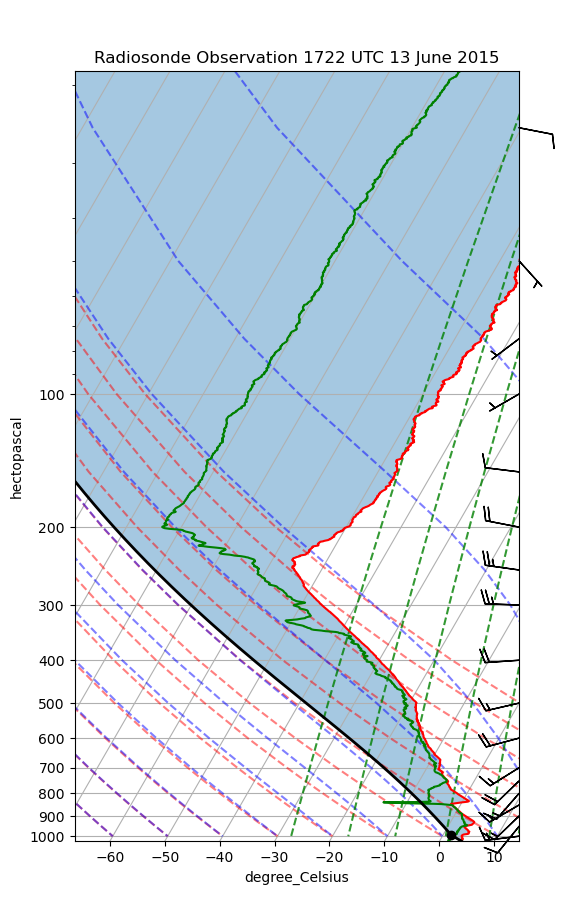

In [199]:
#Individual radiosonde launches
#Select launch of interest
snd = sondes[1]

#Open sounding file
snd_ds = act.io.read_arm_netcdf(snd)
print(snd_ds)

#Plot sounding
skewt = act.plotting.SkewTDisplay(snd_ds, figsize=(15, 10))
skewt.plot_from_u_and_v(
    'u_wind',
    'v_wind',
    'pres',
    'tdry',
    'dp',
    plot_dry_adiabats=True,
    plot_moist_adiabats=True,
    plot_mixing_lines=True,
)
plt.title("Radiosonde Observation 1722 UTC 13 June 2015")
plt.savefig("1722_sounding.png")
plt.show()

<xarray.Dataset> Size: 14MB
Dimensions:            (time: 360, height: 260)
Coordinates:
  * time               (time) datetime64[ns] 3kB 2015-06-13T18:00:30 ... 2015...
  * height             (height) float32 1kB 0.008 0.028 0.048 ... 13.61 13.81
Data variables: (12/39)
    base_time          datetime64[ns] 8B 2015-06-13
    time_offset        (time) datetime64[ns] 3kB 2015-06-13T18:00:30 ... 2015...
    precip             (time) float32 1kB dask.array<chunksize=(360,), meta=np.ndarray>
    qc_precip          (time) int32 1kB dask.array<chunksize=(360,), meta=np.ndarray>
    temp               (time, height) float32 374kB dask.array<chunksize=(360, 260), meta=np.ndarray>
    qc_temp            (time, height) int32 374kB dask.array<chunksize=(360, 260), meta=np.ndarray>
    ...                 ...
    qc_rh_scaled       (time, height) int32 374kB dask.array<chunksize=(360, 260), meta=np.ndarray>
    aqc_rh_scaled      (time, height) int32 374kB dask.array<chunksize=(360, 260), meta=np.

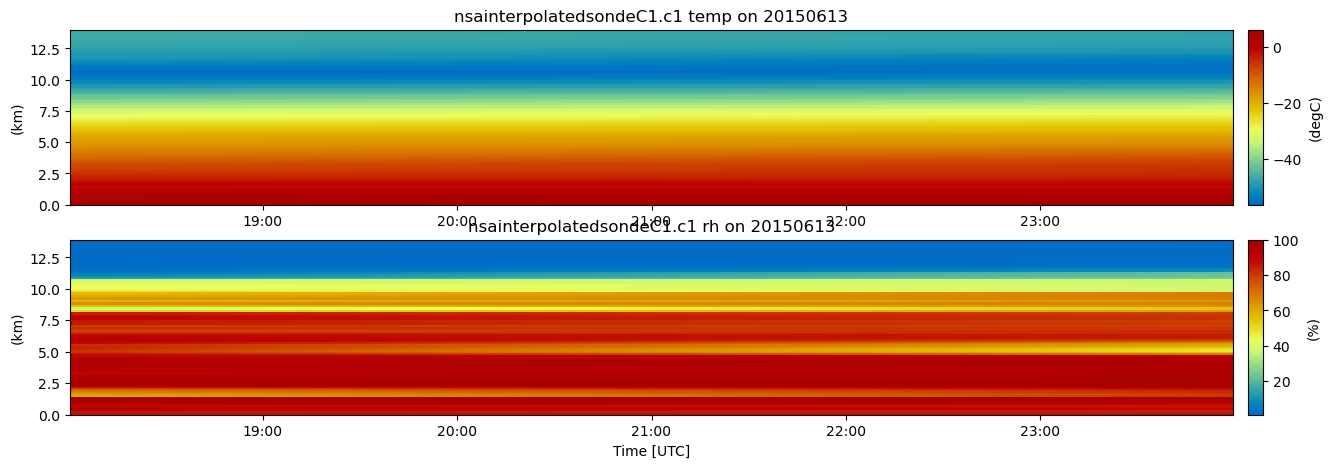

In [184]:
#Interpolated sounding
#Open interpolated sounding
isnd_ds = act.io.read_arm_netcdf(intp)

#Plot interpolated sounding
isnd_prs = isnd_ds.sel(time=slice("2015-06-13T18:00:00", "2015-06-13T23:59:30"))
isnd_prs = isnd_prs.sel(height=slice(0,14))
print(isnd_prs)
display = act.plotting.TimeSeriesDisplay(isnd_prs, subplot_shape=(2,), figsize=(15, 5))
display.plot('temp', subplot_index=(0,), cvd_friendly=True, y_rng = (0,14))
display.plot('rh', subplot_index=(1,), cvd_friendly=True, y_rng = (0,14))
plt.show()

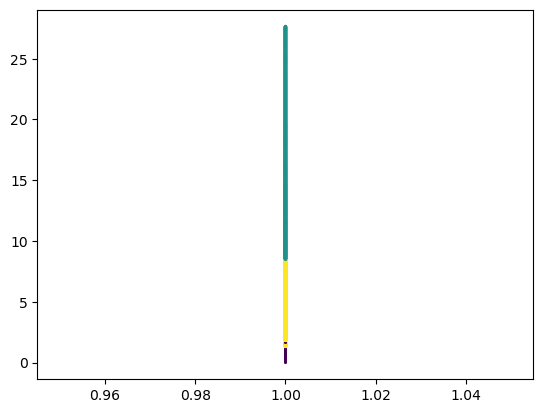

In [185]:
#Temperature classification:
# T > 0C -- liquid/rain (1)
# T < -40C -- ice/snow (2)
# 0C > T > -40C -- depends on other variables (3)

#Single Sounding:
y = []
z = []
x = []

#Define temperature, height, and create a zip folder
temp = snd_ds["tdry"].to_numpy()
hgt = snd_ds["alt"].to_numpy()
th = zip(temp, hgt)

#Append height to y and category to z
#x is defined as 1 for each datapoint to keep line vertical
for h in th:
    h_temp = float(h[0])
    h_hgt = float(h[1])
    y.append(h_hgt/1000)
    if h_temp > 0:
        cat = 1
    if h_temp < -40:
        cat = 2
    if 0 >= h_temp >= -40:
        cat = 3
    z.append(cat)
    x.append(1)
    
#Plot vertical classification
fig, ax = plt.subplots()
ax.scatter(x, y, z, c=z)
plt.show()    

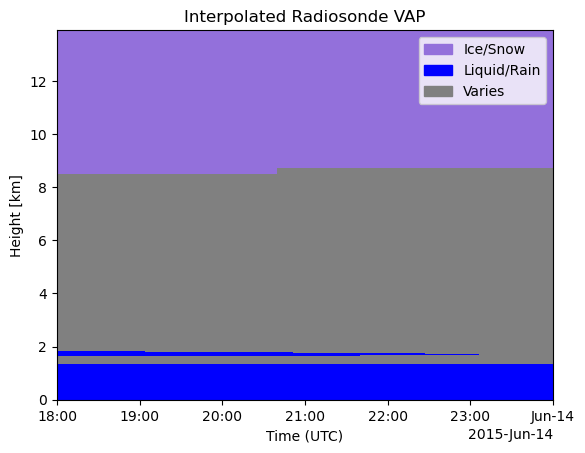

In [202]:
#Interpolation:

#Define time and height
time = isnd_prs.coords["time"]
time_dt = pd.to_datetime(time)

height = isnd_prs.coords["height"]

#Create meshgrid
X, Y = np.meshgrid(time_dt, height)

#Create separate datasets for each classification
ice_ds = isnd_prs.where(isnd_prs.temp < -40)
liquid_ds = isnd_prs.where(isnd_prs.temp > 0)
vari_ds = isnd_prs.where((-40 <= isnd_prs.temp) & (isnd_prs.temp <= 0))

#Create colormaps
ice_cmap = mcolors.ListedColormap(['mediumpurple'])
liquid_cmap = mcolors.ListedColormap(['blue'])
vari_cmap = mcolors.ListedColormap(['grey'])

#Plot all three classifications
xr.plot.pcolormesh(ice_ds.temp, x="time", y="height", cmap = ice_cmap, add_colorbar = False)
xr.plot.pcolormesh(liquid_ds.temp, x="time", y="height", cmap = liquid_cmap, add_colorbar = False)
xr.plot.pcolormesh(vari_ds.temp, x="time", y="height", cmap = vari_cmap, add_colorbar = False)

#Assign labels to classification
ice_patch = mpatches.Patch(color='mediumpurple', label='Ice/Snow')
liquid_patch = mpatches.Patch(color='blue', label='Liquid/Rain')
vari_patch = mpatches.Patch(color='grey', label='Varies')

#Plot legend, title, x label, and save figure
plt.legend(handles=[ice_patch, liquid_patch, vari_patch], loc='upper right')
plt.title("Interpolated Radiosonde VAP")
plt.xlabel("Time (UTC)")
plt.savefig("IRVAP_13June.png")
